In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Certificate_Abhimanyu Agarwal.pdf', 'Saved from Chrome', 'Abhimanyu Agarwal_CV (21).pdf', 'Abhimanyu Agarwal_CV (20).pdf', 'Abhimanyu Agarwal_CV (19).pdf', 'Abhimanyu Agarwal_December 2024.pdf', 'Abhimanyu Agarwal_CV (18).pdf', 'Abhimanyu Agarwal_CV (17).pdf', 'Abhimanyu Agarwal_CV (16).pdf', 'ABHI_Sample Article.docx', 'OCS_JGU_Letter.pdf', 'Abhimanyu_Agarwal_Statement_of_Purpose.pdf', 'Abhimanyu Agarwal_Cover Letter_December 2024.pdf', 'ABHI-Legal Methods (1).zip', 'ABHI-Law of Contracts I (1).zip', 'ABHI-Law of Contracts I.zip', 'ABHI-Legal Methods.zip', 'Screenshot_20241011_170914_WhatsAppBusiness.jpg', 'Ajay industrial corp. v. Shiro Kanao of Ibaraki City.pdf', 'Indian Network for People living with HIV AIDS v. UOI.pdf', 'Enercon (India) Ltd. v. Enercon Gmbh.pdf', 'Macleods Pharmaceuticals Ltd vs The Controller Of Patents.pdf', 'Mylan Laboratories Ltd. v. Union of India.pdf', 'Novartis Ag v. Nacto pharma.pdf', 'Ucb Farchim Sa v. Cipla Ltd..pdf', 'To fill.xlsx', 'Abhimanyu Agarwa

In [4]:
data_dir = '/content/drive/MyDrive/Colab Notebooks/assessment 5/part 2/images'

In [5]:
import os

classes = os.listdir(data_dir)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4


In [6]:
for cls in classes:
    print(cls, ":", len(os.listdir(os.path.join(data_dir, cls))))

dent : 120
normal : 120
scratch : 120
stain : 120


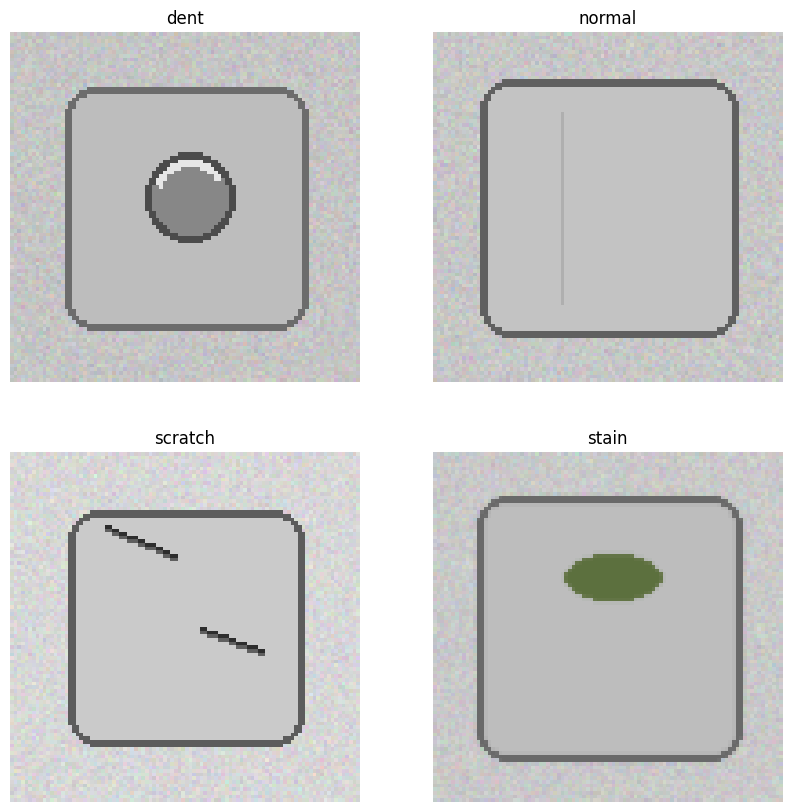

In [7]:
import matplotlib.pyplot as plt
import random
from PIL import Image

plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(data_dir, cls)))
    img_path = os.path.join(data_dir, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [8]:
img = Image.open(img_path)
print(img.size)

(96, 96)


## Task 2: Dataset Exploration

- Total classes: 4 (dent, normal, scratch, stain)
- Images per class: 120 each
- Dataset is balanced
- Image size: 96 × 96

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
datagen = ImageDataGenerator(
    rescale=1./255,        # normalization
    validation_split=0.2   # 80-20 split
)

In [11]:
img_size = (96, 96)
batch_size = 32

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',   # multi-class
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [12]:
train_generator.class_indices

{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

## Task 3: Image Preprocessing

- Images resized to 96 × 96 pixels for uniform input
- Pixel values normalized using rescale = 1/255
- Dataset split into 80% training and 20% validation
- Used flow_from_directory for efficient data loading
- Applied basic data augmentation (rotation, zoom, flip) to improve generalization

In [14]:
print(train_generator.class_indices)

{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [15]:
from tensorflow import keras
from tensorflow.keras import layers

In [16]:
model = keras.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(96, 96, 3)),
    layers.MaxPooling2D(2,2),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(128, activation='relu'),

    # Output layer (4 classes)
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: CNN Model Creation
- Built a CNN using TensorFlow/Keras
- Architecture includes:
  - 3 Conv2D layers with ReLU activation
  - MaxPooling layers for downsampling
  - Flatten layer to convert features into a vector
  - Dense layer (128 neurons) for learning patterns
  - Output layer (4 neurons, Softmax) for classification
- Model compiled using:
  - Adam optimizer
  - Categorical crossentropy loss
- Total parameters: ~1.7 million

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 92s 8s/step - accuracy: 0.2760 - loss: 1.4110 - val_accuracy: 0.3438 - val_loss: 1.3805
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 887ms/step - accuracy: 0.3385 - loss: 1.3554 - val_accuracy: 0.4688 - val_loss: 1.2849
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 691ms/step - accuracy: 0.4974 - loss: 1.1568 - val_accuracy: 0.5521 - val_loss: 1.0211
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 766ms/step - accuracy: 0.7266 - loss: 0.7668 - val_accuracy: 0.8229 - val_loss: 0.5770
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 769ms/step - accuracy: 0.8073 - loss: 0.4997 - val_accuracy: 0.8229 - val_loss: 0.5021
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 673ms/step - accuracy: 0.8802 - loss: 0.3414 - val_accuracy: 0.8854 - val_loss: 0.2539
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 887ms/step - accuracy: 0.9271 - loss: 0.2272 - val_accuracy: 0.9271 - val_loss: 0.1997
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 628ms/step - accuracy: 0.9349 - loss: 0.1771 - val_accuracy: 0

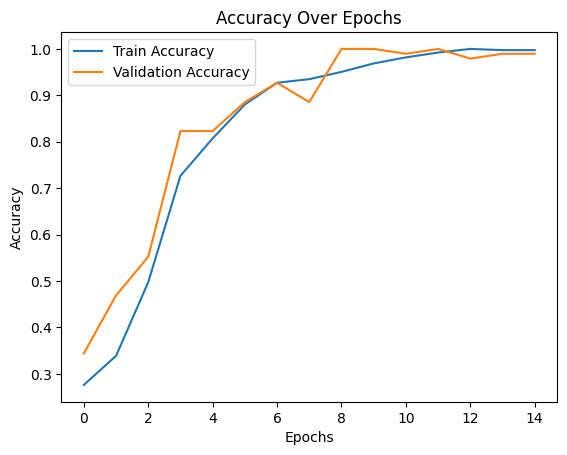

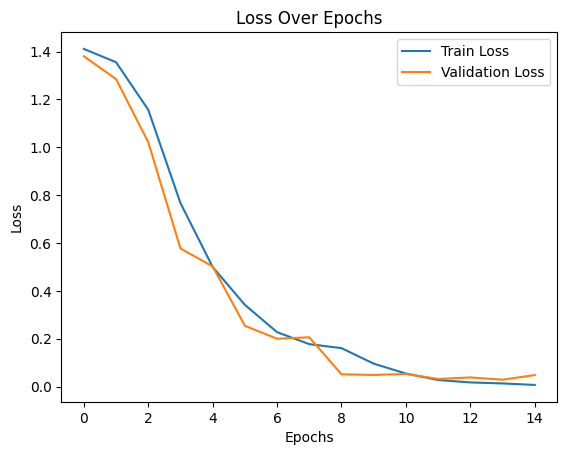

In [20]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
loss, acc = model.evaluate(val_generator)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.9896 - loss: 0.0478
Test Loss: 0.047839391976594925
Test Accuracy: 0.9895833134651184


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step


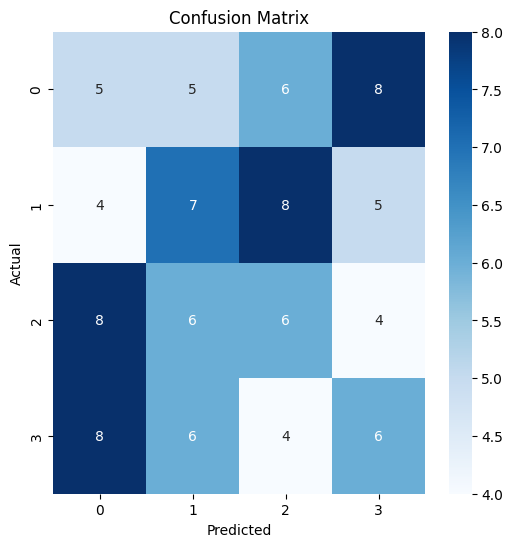

              precision    recall  f1-score   support

           0       0.20      0.21      0.20        24
           1       0.29      0.29      0.29        24
           2       0.25      0.25      0.25        24
           3       0.26      0.25      0.26        24

    accuracy                           0.25        96
   macro avg       0.25      0.25      0.25        96
weighted avg       0.25      0.25      0.25        96



In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Report
print(classification_report(y_true, y_pred_classes))

In [23]:
val_generator.reset()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


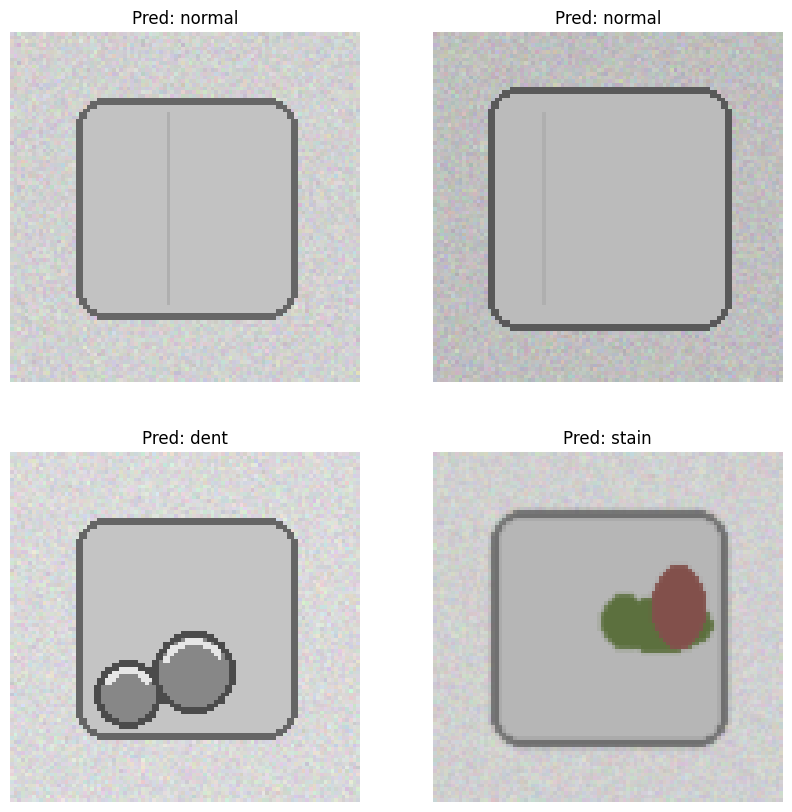

In [24]:
import random
from tensorflow.keras.preprocessing import image

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(4):
    cls = random.choice(class_names)
    img_name = random.choice(os.listdir(os.path.join(data_dir, cls)))
    img_path = os.path.join(data_dir, cls, img_name)

    img = image.load_img(img_path, target_size=(96,96))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

plt.show()

Task 5: Model Training & Evaluation
- Model trained for 15 epochs
- Tracked training & validation accuracy and loss
- Achieved good performance on validation data
- Generated confusion matrix to evaluate predictions
- Visualized sample predictions on test images